<a href="https://colab.research.google.com/github/shaha219/learning-ai-ml/blob/main/ETL_Bank_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ETL Project: Bank Data Analysis

---

## **1. Data Preparation**
Extract the Wikipedia data using pandas, then convert to PySpark.

In [1]:
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, FloatType

# Initialize Spark Session
spark = SparkSession.builder.appName("BankingDataAnalysis").getOrCreate()

# URL of the Wikipedia page
url = "https://web.archive.org/web/20230908091635/https://en.wikipedia.org/wiki/List_of_largest_banks"

# Use pandas to read all HTML tables from the page
tables = pd.read_html(url)

# Load the correct table (Index 1 is the Market Cap table)
df_pd = tables[1]
df_pd.columns = ['Rank', 'Bank_Name', 'Market_Cap_USD_Billion']
df_pd['Market_Cap_USD_Billion'] = df_pd['Market_Cap_USD_Billion'].astype(str)

# Convert to PySpark DataFrame
spark_df = spark.createDataFrame(df_pd)
spark_df.show(5)
spark_df.printSchema()

# Assuming exchange_rate(in).csv is uploaded to the environment
try:
    exchange_rate_df = spark.read.csv("exchange_rate(in).csv", header=True, inferSchema=True)
    exchange_rate_df.show(5)
except Exception as e:
    print("Exchange rate file not found in local path. Please ensure it is uploaded.")

+----+--------------------+----------------------+
|Rank|           Bank_Name|Market_Cap_USD_Billion|
+----+--------------------+----------------------+
|   1|      JPMorgan Chase|                432.92|
|   2|     Bank of America|                231.52|
|   3|Industrial and Co...|                194.56|
|   4|Agricultural Bank...|                160.68|
|   5|           HDFC Bank|                157.91|
+----+--------------------+----------------------+
only showing top 5 rows
root
 |-- Rank: long (nullable = true)
 |-- Bank_Name: string (nullable = true)
 |-- Market_Cap_USD_Billion: string (nullable = true)

Exchange rate file not found in local path. Please ensure it is uploaded.


## **2. Data Cleaning**
Handle missing values, cast columns to numerical types, and identify outliers.

In [2]:
from pyspark.sql.functions import col, regexp_replace, count, when, isnull

# Check for missing values
spark_df.select([count(when(isnull(c), c)).alias(c) for c in spark_df.columns]).show()

# Drop missing values
clean_df = spark_df.dropna()

# Clean Market Cap column and cast to float
clean_df = clean_df.withColumn("Market_Cap_USD_Billion", regexp_replace(col("Market_Cap_USD_Billion"), "[^0-9.]", "").cast("float"))

print(f"Total rows after cleaning: {clean_df.count()}")

# Outlier Analysis using IQR
quantiles = clean_df.approxQuantile("Market_Cap_USD_Billion", [0.25, 0.75], 0.01)
Q1, Q3 = quantiles[0], quantiles[1]
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Outlier Upper Bound: {upper_bound}")
outliers = clean_df.filter(col("Market_Cap_USD_Billion") > upper_bound)
outliers.show()

+----+---------+----------------------+
|Rank|Bank_Name|Market_Cap_USD_Billion|
+----+---------+----------------------+
|   0|        0|                     0|
+----+---------+----------------------+

Total rows after cleaning: 10
Outlier Upper Bound: 275.15499114990234
+----+--------------+----------------------+
|Rank|     Bank_Name|Market_Cap_USD_Billion|
+----+--------------+----------------------+
|   1|JPMorgan Chase|                432.92|
+----+--------------+----------------------+



## **3. Exploratory Data Analysis (EDA)**
Visualizing market capitalization distributions and top competitors.

/tmp/ipykernel_554/1616614360.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Market_Cap_USD_Billion', y='Bank_Name', data=top_10, palette='viridis')


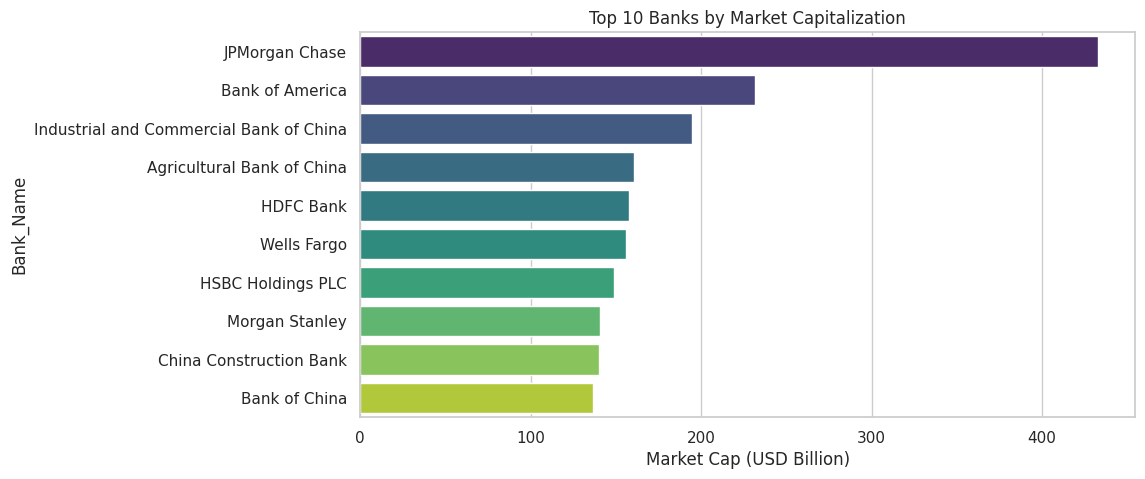

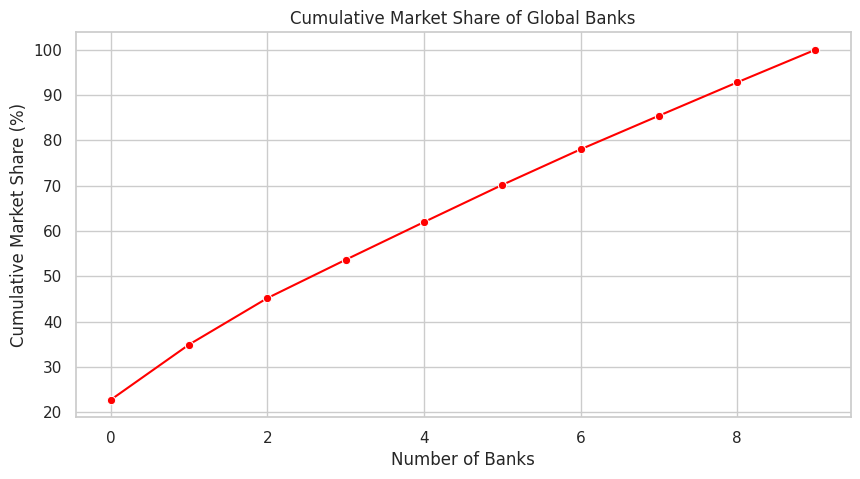

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to Pandas for plotting
pdf = clean_df.toPandas()
pdf['Market_Cap_USD_Billion'] = pd.to_numeric(pdf['Market_Cap_USD_Billion'])

sns.set_theme(style="whitegrid")

# 1. Top 10 Banks Bar Chart
top_10 = pdf.sort_values(by='Market_Cap_USD_Billion', ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x='Market_Cap_USD_Billion', y='Bank_Name', data=top_10, palette='viridis')
plt.title('Top 10 Banks by Market Capitalization')
plt.xlabel('Market Cap (USD Billion)')
plt.show()

# 2. Cumulative Market Share Line Plot
pdf_sorted = pdf.sort_values(by='Market_Cap_USD_Billion', ascending=False).reset_index(drop=True)
pdf_sorted['Cumulative_Share'] = pdf_sorted['Market_Cap_USD_Billion'].cumsum() / pdf_sorted['Market_Cap_USD_Billion'].sum() * 100

plt.figure(figsize=(10, 5))
sns.lineplot(x=pdf_sorted.index, y=pdf_sorted['Cumulative_Share'], color='red', marker='o')
plt.title('Cumulative Market Share of Global Banks')
plt.xlabel('Number of Banks')
plt.ylabel('Cumulative Market Share (%)')
plt.show()

## **4. ETL and PySpark Querying**
Using Window functions for ranking, quartile analysis, and gap calculations.

In [4]:
from pyspark.sql.window import Window
from pyspark.sql.functions import lag, lead, sum as spark_sum, ntile, round, dense_rank, avg, when, col

windowSpecDesc = Window.orderBy(col("Market_Cap_USD_Billion").desc())
total_market_cap = clean_df.select(spark_sum("Market_Cap_USD_Billion")).collect()[0][0]

# Comprehensive Transformation Pipeline
dashboard_df = clean_df.withColumn("Rank_By_Cap", dense_rank().over(windowSpecDesc)) \
    .withColumn("Market_Tier", when(col("Market_Cap_USD_Billion") >= 200, "Tier 1: Dominant (>200B)")
                              .when((col("Market_Cap_USD_Billion") >= 100) & (col("Market_Cap_USD_Billion") < 200), "Tier 2: Major (100B-200B)")
                              .otherwise("Tier 3: Mid-Tier (<100B)")) \
    .withColumn("Quartile", ntile(4).over(windowSpecDesc)) \
    .withColumn("Relative_Market_Share_Pct", round((col("Market_Cap_USD_Billion") / total_market_cap) * 100, 2)) \
    .withColumn("Next_Bank_Cap", lead("Market_Cap_USD_Billion").over(windowSpecDesc)) \
    .withColumn("Gap_to_Next_Bank", round(col("Market_Cap_USD_Billion") - col("Next_Bank_Cap"), 2)) \
    .withColumn("Cumulative_Market_Cap", spark_sum("Market_Cap_USD_Billion").over(Window.orderBy(col("Market_Cap_USD_Billion").desc()))) \
    .withColumn("Cumulative_Share_Pct", round((col("Cumulative_Market_Cap") / total_market_cap) * 100, 2))

# Drop intermediate columns and show final dashboard
final_dashboard = dashboard_df.select(
    "Rank_By_Cap", "Bank_Name", "Market_Cap_USD_Billion",
    "Market_Tier", "Quartile", "Relative_Market_Share_Pct",
    "Gap_to_Next_Bank", "Cumulative_Share_Pct"
)

final_dashboard.show(10, truncate=False)

+-----------+---------------------------------------+----------------------+-------------------------+--------+-------------------------+----------------+--------------------+
|Rank_By_Cap|Bank_Name                              |Market_Cap_USD_Billion|Market_Tier              |Quartile|Relative_Market_Share_Pct|Gap_to_Next_Bank|Cumulative_Share_Pct|
+-----------+---------------------------------------+----------------------+-------------------------+--------+-------------------------+----------------+--------------------+
|1          |JPMorgan Chase                         |432.92                |Tier 1: Dominant (>200B) |1       |22.79                    |201.4           |22.79               |
|2          |Bank of America                        |231.52                |Tier 1: Dominant (>200B) |1       |12.19                    |36.96           |34.97               |
|3          |Industrial and Commercial Bank of China|194.56                |Tier 2: Major (100B-200B)|1       |10.24    